In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Better_Dataset.csv")

df.head()

,date,temperature,humidity,verdict
0,2024-03-01 00:00:00,24.912950,36.451926,1
1,2024-03-01 04:00:00,31.259358,50.668960,0
2,2024-03-01 08:00:00,29.988245,55.987899,0
3,2024-03-01 12:00:00,35.314738,56.160208,0
4,2024-03-01 16:00:00,26.163837,48.280121,1


In [3]:
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2311 entries, 0 to 2310
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2311 non-null   datetime64[ns]
 1   temperature  2311 non-null   float64       
 2   humidity     2311 non-null   float64       
 3   verdict      2311 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 72.3 KB


In [4]:
df = df.set_index("date")

df.head()

,temperature,humidity,verdict
date,,,
2024-03-01 00:00:00,24.912950,36.451926,1
2024-03-01 04:00:00,31.259358,50.668960,0
2024-03-01 08:00:00,29.988245,55.987899,0
2024-03-01 12:00:00,35.314738,56.160208,0
2024-03-01 16:00:00,26.163837,48.280121,1


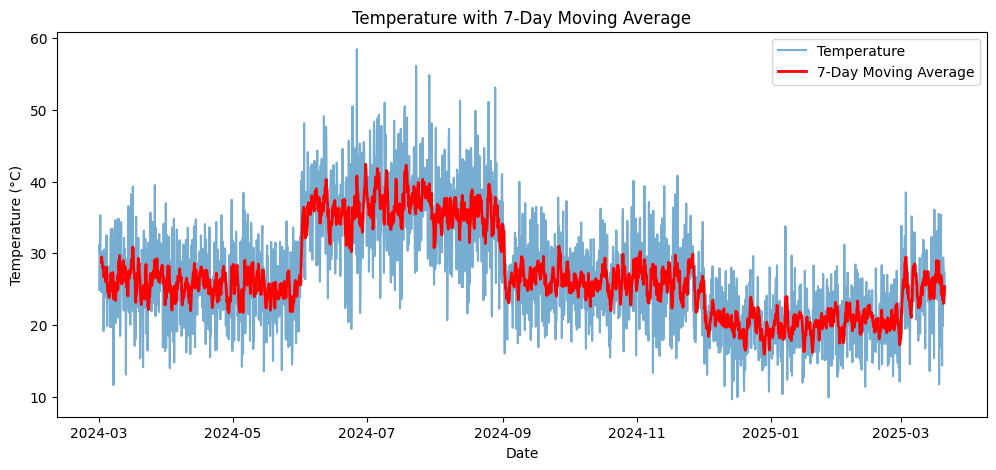

In [5]:
# Calculate 7-day Moving Average
df["Moving_Average"] = df["temperature"].rolling(window=7).mean()

# Plot Temperature and Moving Average
plt.figure(figsize=(12,5))
plt.plot(df.index, df["temperature"], label="Temperature", alpha=0.6)
plt.plot(df.index, df["Moving_Average"], color="red", linewidth=2, label="7-Day Moving Average")

plt.title("Temperature with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

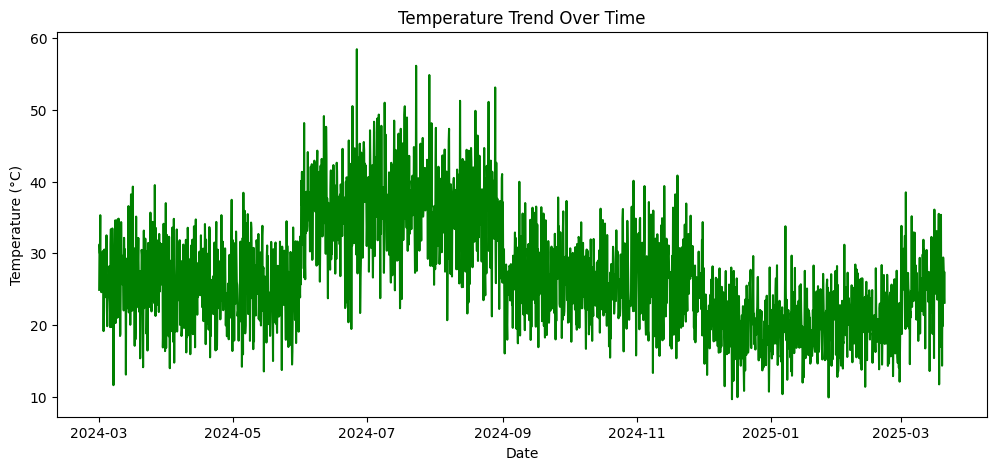

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["temperature"], color="green")

plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Create numeric index
df["Day"] = np.arange(len(df))

X = df[["Day"]]
y = df["temperature"]

model = LinearRegression()
model.fit(X, y)

df["Predicted_Temperature"] = model.predict(X)

print("Forecast model created successfully!")

Forecast model created successfully!


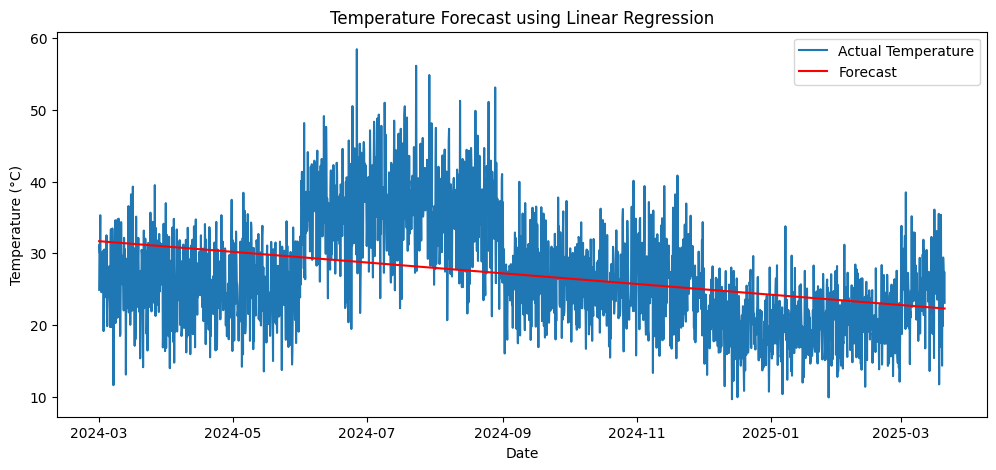

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["temperature"], label="Actual Temperature")
plt.plot(df.index, df["Predicted_Temperature"], color="red", label="Forecast")

plt.title("Temperature Forecast using Linear Regression")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()